In [ ]:
import numpy as np
import PyWSINDy_ODE.wsindy as ws
import PyWSINDy_ODE.ODE_examples as ODE_examples 
import matplotlib.pylab as plt
from scipy.integrate import solve_ivp

def addNoise(x, noise_ratio):
    signal_power = np.sqrt(np.mean(x**2))
    sigma = noise_ratio*signal_power
    noise = np.random.normal(0, sigma, x.shape)
    xobs = x + noise
    return xobs

def recoverDynamics(model):

    coeffs = model.coef
    tags = model.tags
    num_states = coeffs.shape[1]

    for i in range(num_states):
        equation_terms = []
        for j in range(len(tags)):
            c = coeffs[j, i]
            if np.abs(c) > 1e-5: 
                
                powers = tags[j]
                monomial = ""
                
                for k in range(len(powers)):
                    p = powers[k]
                    if p == 1:
                        monomial += f"x{k}"
                    elif p > 1:
                        monomial += f"x{k}^{int(p)}"
                
                if monomial == "": 
                    equation_terms.append(f"{c:.4f}")
                else:
                    equation_terms.append(f"({c:.4f}){monomial}")
        
        equation_str = " + ".join(equation_terms).replace("+ -", "- ")
        print(f"dx{i}/dt = {equation_str}")



True The solver successfully reached the end of the integration interval. 59.99 (6000, 3)


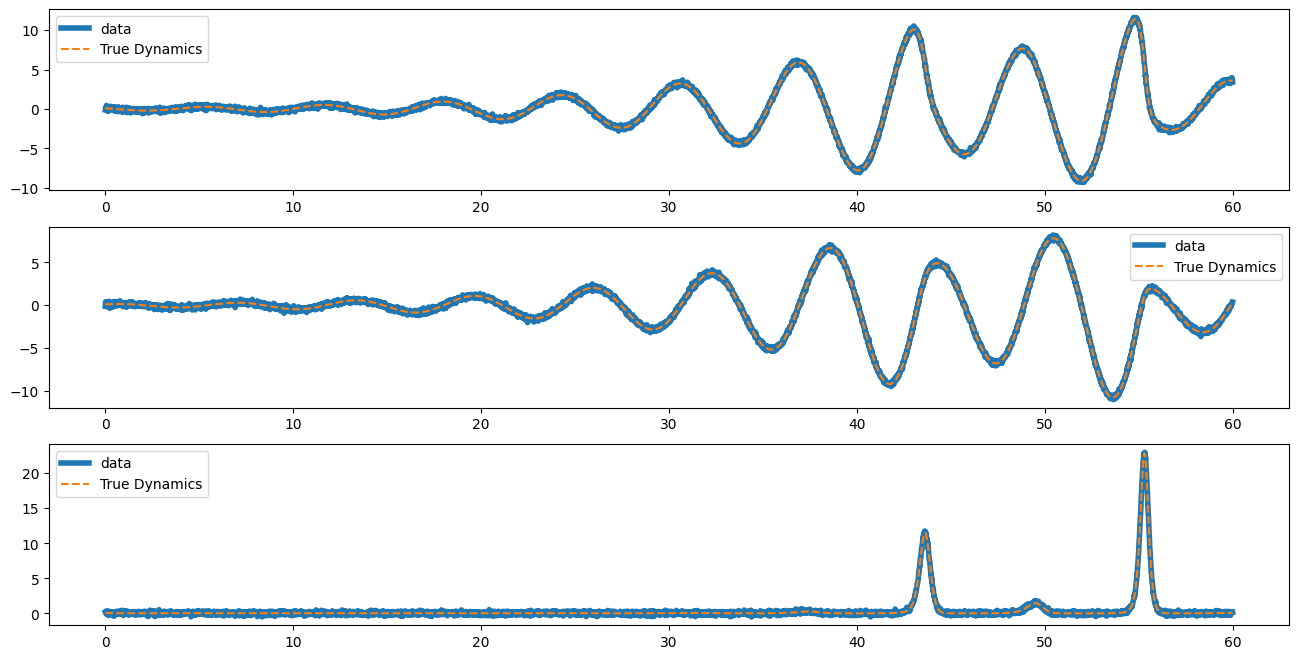

In [31]:
t_span = np.array([0,60])
t_eval = np.arange(0,60,0.01)
noise_ratio = 0.05



a = 0.2
b = 0.2 
c = 5.7

def rhs(t, s):
            # z = [x, y, eta, mx, cx, my, cy]
            x, y, z = s



            dx = -y-z
            dy = x+a*y
            dz = b+z*(x-c)



            return np.array([dx, dy, dz])

x0 = np.array([0.1 ,0.1 ,0.1]).T


sol = solve_ivp(fun=rhs, t_eval=t_eval, t_span=t_span, y0=x0, rtol=1e-6)
print(sol.success, sol.message, sol.t[-1], sol.y.T.shape)


x = sol.y.T
t = sol.t
xobs = addNoise(x=sol.y.T,noise_ratio=noise_ratio)

# plt.plot(sol.t,xobs)
fig = plt.figure(figsize=(16, 8))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], "--", label = 'True Dynamics',)
    c = c + 1
    plt.legend()

In [34]:
WSINDy_model = ws.wsindy(polys=np.arange(0, 4),ld=0.05
                         )

#Uniform
WSINDy_model.getWSindyUniform(xobs, t, L = 30, overlap=0.7)

t_ws, WSINDy_sim = WSINDy_model.simulate(t_span = [t[0],t[-1]], t_eval = t, x0 = xobs[0,:])
print_recovered_dynamics(WSINDy_model)

True The solver successfully reached the end of the integration interval. 59.99 (6000, 3)
Recovered Dynamics:
--------------------
dx0/dt = (-1.0060)x2 + (-1.0021)x1 + (0.0040)x1x2
dx1/dt = (0.2003)x1 + (0.9994)x0
dx2/dt = 0.1724 + (-5.3611)x2 + (-0.0106)x2^2 + (-0.0380)x1x2 + (0.9763)x0x2


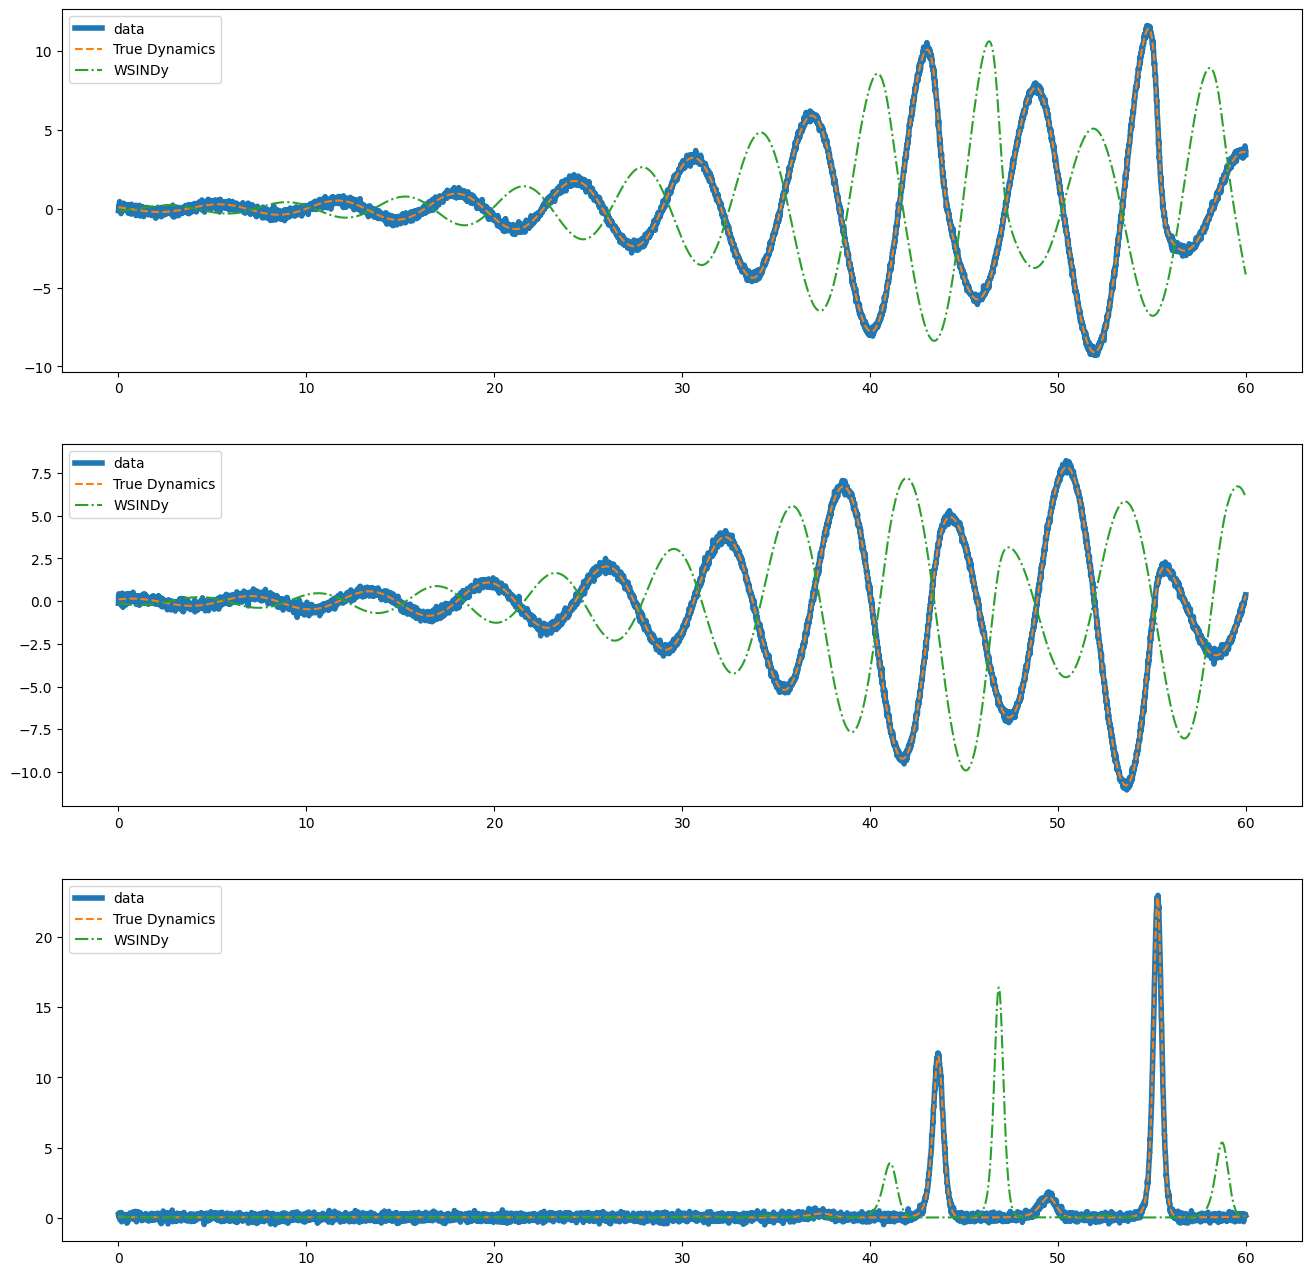

In [33]:
fig = plt.figure(figsize=(16, 16))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, x[:, d], linestyle = "--", label = 'True Dynamics',) #marker = 'o', markevery=300)
    plt.plot(t_ws, WSINDy_sim[:, d], linestyle='dashdot', label = 'WSINDy') #marker = 'v', markevery = 200)
    
    c = c + 1
    plt.legend()